In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv("data/text2.csv")

In [9]:
ls

README.md         data/             notebooks/        src/
app/              models/           requirements.txt  venv/


In [10]:
# 1. BASIC DATASET INFORMATION

In [11]:
print("\n===== DATASET SHAPE =====")
print(df.shape)

print("\n===== COLUMN NAMES =====")
print(df.columns.tolist())

print("\n===== FIRST 5 ROWS =====")
display(df.head())

print("\n===== LAST 5 ROWS =====")
display(df.tail())

print("\n===== DATA TYPES =====")
print(df.dtypes)

print("\n===== DATASET INFO =====")
df.info()


===== DATASET SHAPE =====
(416809, 5)

===== COLUMN NAMES =====
['Unnamed: 0', 'text', 'label', 'sentiment', 'emoji_augmented']

===== FIRST 5 ROWS =====


,Unnamed: 0,text,label,sentiment,emoji_augmented
0,0,i just feel really helpless and heavy hearted 😨 🙁,4,negative,True
1,1,ive enjoyed being able to slouch about relax a...,0,positive,False
2,2,i gave up my internship with the dmrg and am f...,4,neutral,False
3,3,i dont know i feel so lost,0,negative,False
4,4,i am a kindergarten teacher and i am thoroughl...,4,negative,False



===== LAST 5 ROWS =====


,Unnamed: 0,text,label,sentiment,emoji_augmented
416804,416804,i feel like telling these horny devils to find...,2,neutral,False
416805,416805,i began to realize that when i was feeling agi...,3,neutral,True
416806,416806,i feel very curious be why previous early dawn...,5,neutral,False
416807,416807,i feel that becuase of the tyranical nature of...,3,neutral,False
416808,416808,i think that after i had spent some time inves...,5,neutral,False



===== DATA TYPES =====
Unnamed: 0          int64
text               object
label               int64
sentiment          object
emoji_augmented      bool
dtype: object

===== DATASET INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416809 entries, 0 to 416808
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Unnamed: 0       416809 non-null  int64 
 1   text             416809 non-null  object
 2   label            416809 non-null  int64 
 3   sentiment        416809 non-null  object
 4   emoji_augmented  416809 non-null  bool  
dtypes: bool(1), int64(2), object(2)
memory usage: 13.1+ MB


In [12]:
# 2. MISSING VALUES

In [13]:
print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== MISSING VALUE PERCENTAGE =====")
print((df.isnull().sum() / len(df) * 100).round(2))

missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) > 0:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing.index, y=missing.values)
    plt.title("Missing Values by Column")
    plt.xlabel("Column")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")


===== MISSING VALUES =====
Unnamed: 0         0
text               0
label              0
sentiment          0
emoji_augmented    0
dtype: int64

===== MISSING VALUE PERCENTAGE =====
Unnamed: 0         0.0
text               0.0
label              0.0
sentiment          0.0
emoji_augmented    0.0
dtype: float64
No missing values found.


In [14]:
# 3. DUPLICATE ROWS

In [15]:
duplicate_rows = df.duplicated().sum()
print("\n===== DUPLICATE ROWS =====")
print(duplicate_rows)
print(f"Duplicate percentage: {duplicate_rows / len(df) * 100:.2f}%")


===== DUPLICATE ROWS =====
0
Duplicate percentage: 0.00%


In [16]:
# 4. UNIQUE VALUES

In [17]:
print("\n===== UNIQUE SENTIMENTS =====")
print(df["sentiment"].unique())

print("\n===== UNIQUE EMOTION LABELS =====")
print(sorted(df["label"].unique()))

print("\n===== NUMBER OF UNIQUE TEXTS =====")
print(df["text"].nunique())


===== UNIQUE SENTIMENTS =====
['negative' 'positive' 'neutral']

===== UNIQUE EMOTION LABELS =====
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

===== NUMBER OF UNIQUE TEXTS =====
416123


In [18]:
# 5. SENTIMENT DISTRIBUTION


===== SENTIMENT DISTRIBUTION =====
sentiment
neutral     257218
positive     91786
negative     67805
Name: count, dtype: int64


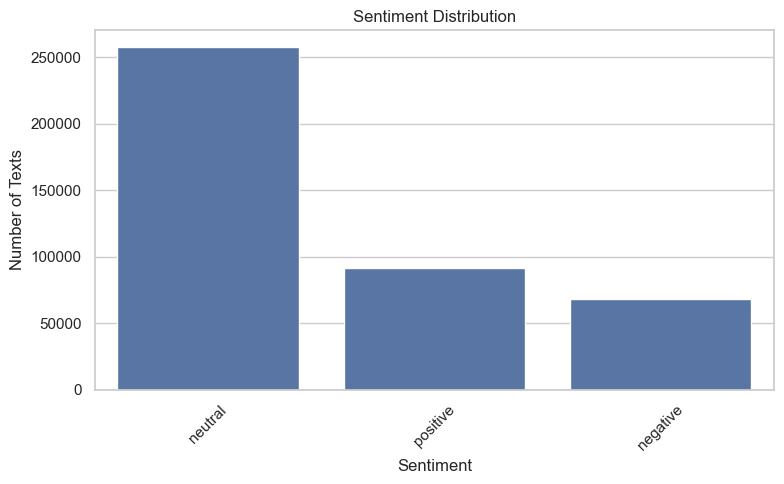

In [19]:
print("\n===== SENTIMENT DISTRIBUTION =====")
print(df["sentiment"].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="sentiment",
              order=df["sentiment"].value_counts().index)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Texts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# 6. EMOTION DISTRIBUTION


===== EMOTION DISTRIBUTION =====
label
0    121187
1    141067
2     34554
3     57317
4     47712
5     14972
Name: count, dtype: int64


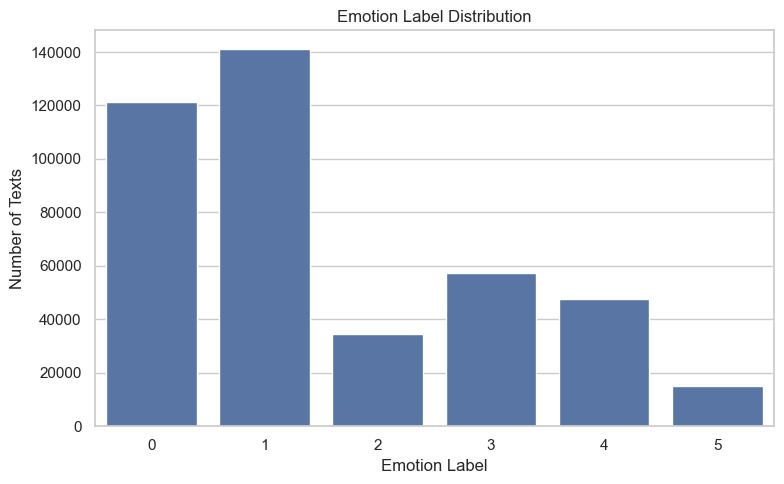

In [21]:
print("\n===== EMOTION DISTRIBUTION =====")
print(df["label"].value_counts().sort_index())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="label",
              order=sorted(df["label"].unique()))
plt.title("Emotion Label Distribution")
plt.xlabel("Emotion Label")
plt.ylabel("Number of Texts")
plt.tight_layout()
plt.show()

In [22]:
# 7. EMOTION BY SENTIMENT

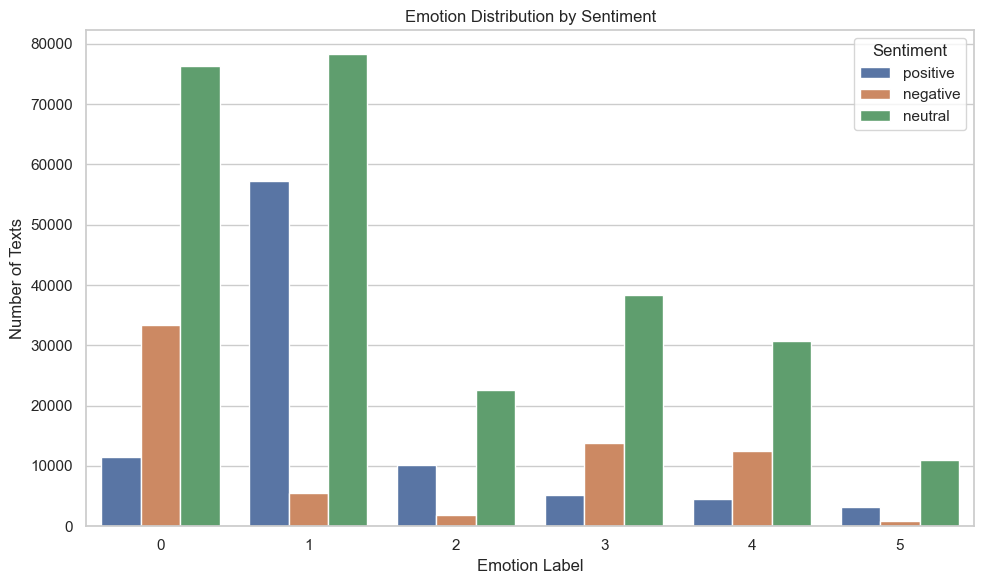

In [23]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="label", hue="sentiment")
plt.title("Emotion Distribution by Sentiment")
plt.xlabel("Emotion Label")
plt.ylabel("Number of Texts")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [24]:
# 8. TEXT LENGTH ANALYSIS


===== TEXT LENGTH STATISTICS =====


count    416809.000000
mean         97.481184
std          56.245345
min           4.000000
25%          54.000000
50%          86.000000
75%         129.000000
max         830.000000
Name: text_length, dtype: float64

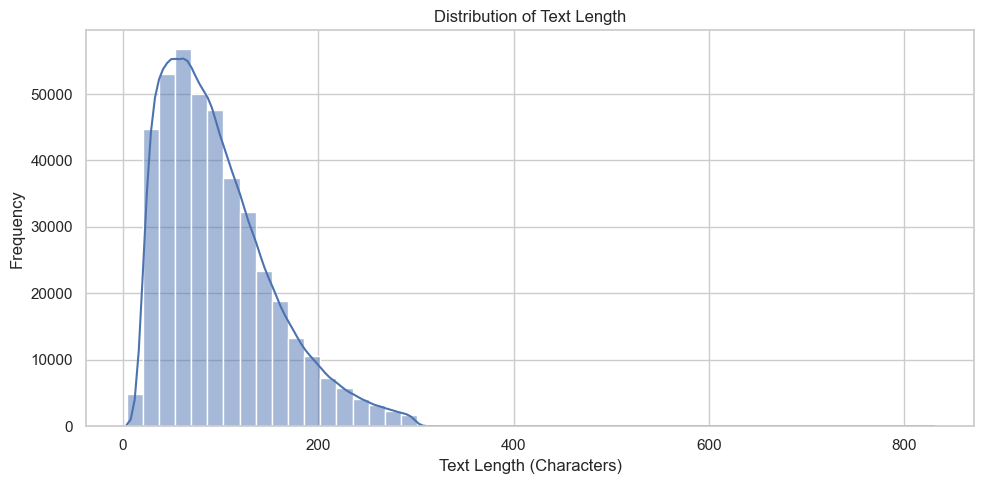

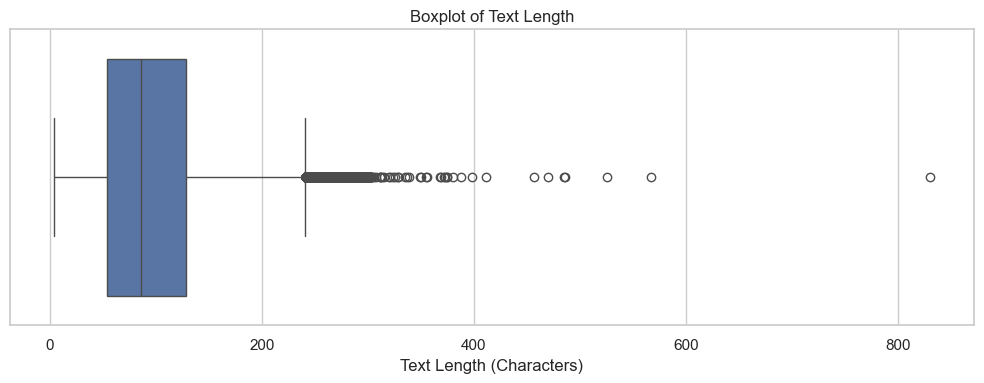

In [25]:
df["text_length"] = df["text"].astype(str).str.len()

print("\n===== TEXT LENGTH STATISTICS =====")
display(df["text_length"].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df["text_length"], bins=50, kde=True)
plt.title("Distribution of Text Length")
plt.xlabel("Text Length (Characters)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=df["text_length"])
plt.title("Boxplot of Text Length")
plt.xlabel("Text Length (Characters)")
plt.tight_layout()
plt.show()

In [26]:
# 9. TEXT LENGTH BY EMOTION

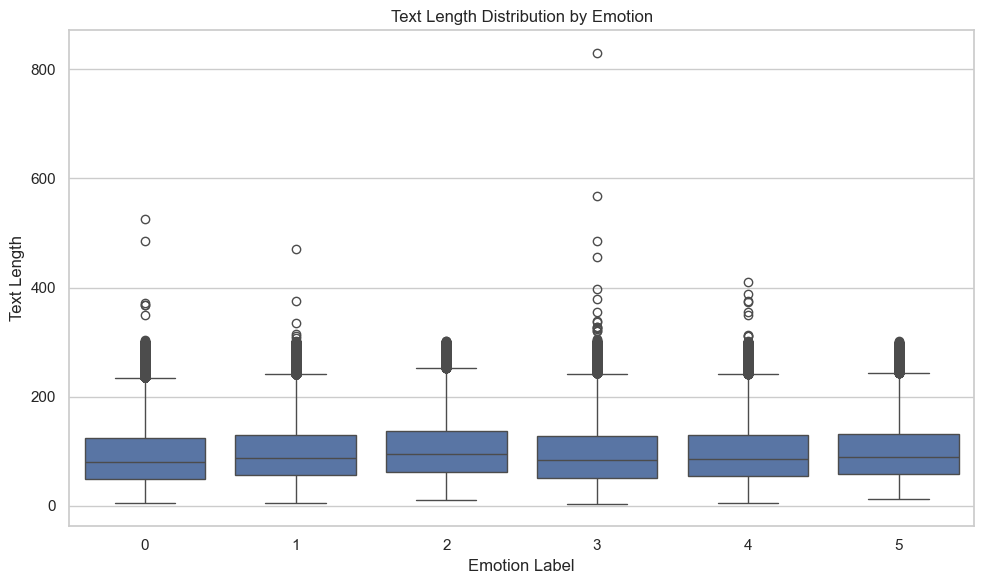

In [27]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="label", y="text_length")
plt.title("Text Length Distribution by Emotion")
plt.xlabel("Emotion Label")
plt.ylabel("Text Length")
plt.tight_layout()
plt.show()

In [28]:
# 10. TEXT LENGTH BY SENTIMENT

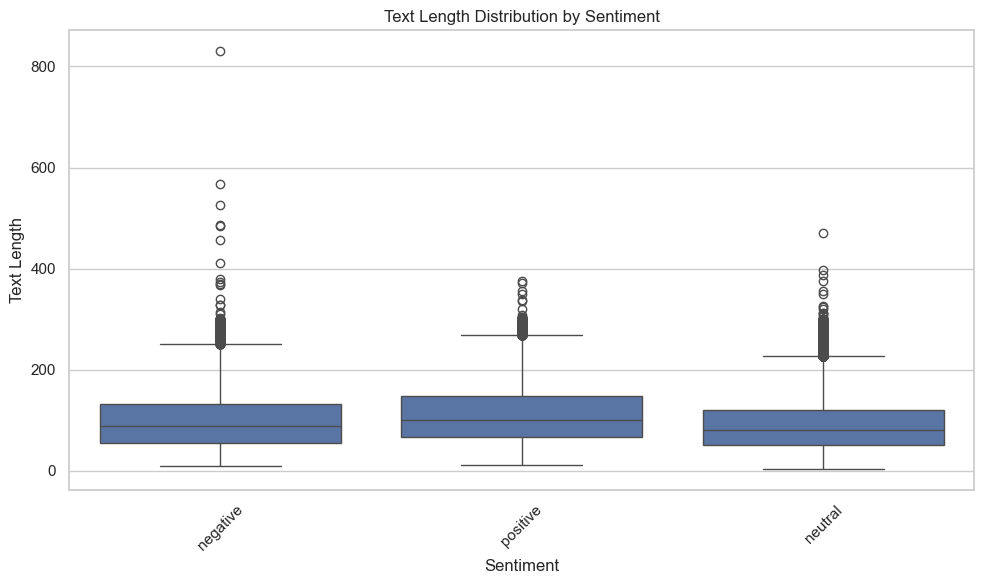

In [29]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="sentiment", y="text_length")
plt.title("Text Length Distribution by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Text Length")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# 11. TEXT LENGTH CATEGORIES


===== TEXT LENGTH CATEGORIES =====
text_length_category
Medium       156495
Long         142371
Short         92516
Very Long     25427
Name: count, dtype: int64


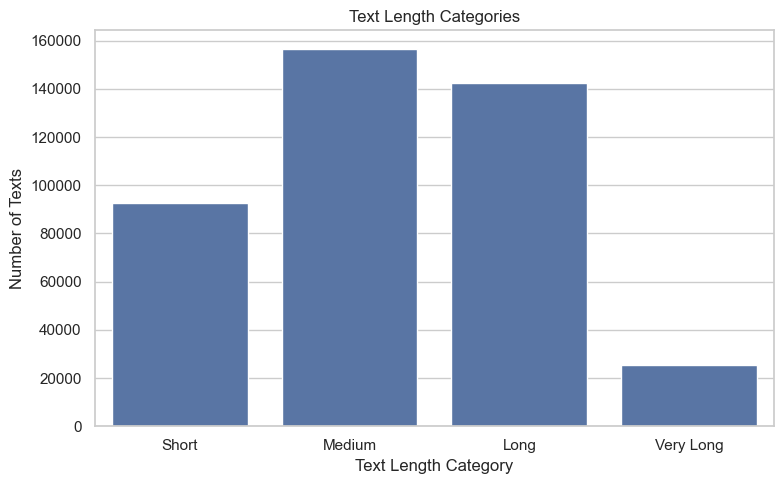

In [31]:
def categorize_length(length):
    if length <= 50:
        return "Short"
    elif length <= 100:
        return "Medium"
    elif length <= 200:
        return "Long"
    else:
        return "Very Long"

df["text_length_category"] = df["text_length"].apply(categorize_length)

print("\n===== TEXT LENGTH CATEGORIES =====")
print(df["text_length_category"].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="text_length_category",
    order=["Short", "Medium", "Long", "Very Long"]
)
plt.title("Text Length Categories")
plt.xlabel("Text Length Category")
plt.ylabel("Number of Texts")
plt.tight_layout()
plt.show()

In [32]:
# 12. TEXT LENGTH CATEGORY × EMOTION


===== TEXT LENGTH CATEGORY × EMOTION =====


label,0,1,2,3,4,5
text_length_category,,,,,,
Long,38160,49898,13541,18973,16291,5508
Medium,45213,53733,12982,21086,17835,5646
Short,31052,28838,5428,13652,10685,2861
Very Long,6762,8598,2603,3606,2901,957


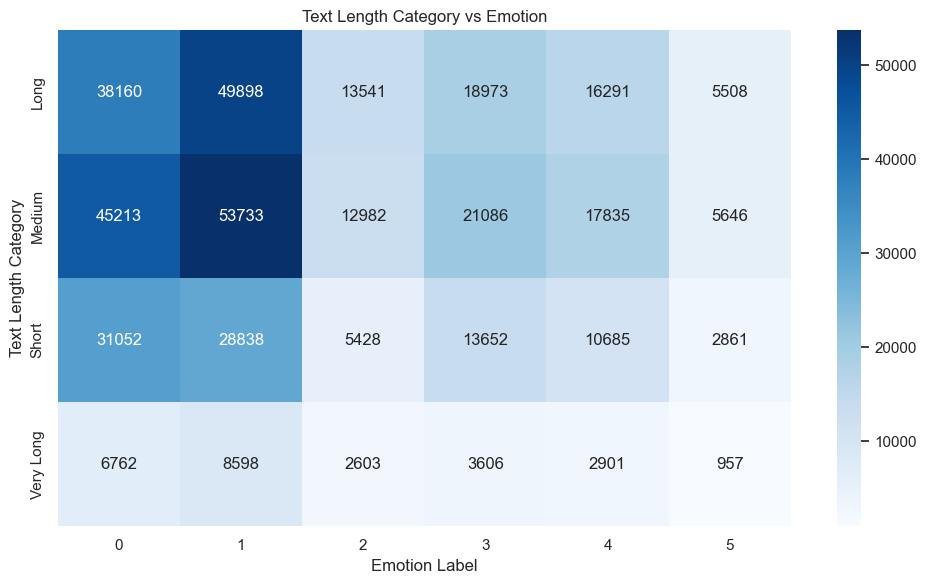

In [33]:
length_emotion = pd.crosstab(
    df["text_length_category"],
    df["label"]
)

print("\n===== TEXT LENGTH CATEGORY × EMOTION =====")
display(length_emotion)

plt.figure(figsize=(10, 6))
sns.heatmap(length_emotion, annot=True, fmt="d", cmap="Blues")
plt.title("Text Length Category vs Emotion")
plt.xlabel("Emotion Label")
plt.ylabel("Text Length Category")
plt.tight_layout()
plt.show()

In [34]:
# 13. SENTIMENT × EMOTION CONTINGENCY TABLE

In [35]:
sentiment_emotion = pd.crosstab(df["sentiment"], df["label"])

print("\n===== SENTIMENT × EMOTION =====")
display(sentiment_emotion)


===== SENTIMENT × EMOTION =====


label,0,1,2,3,4,5
sentiment,,,,,,
negative,33330,5485,1789,13783,12521,897
neutral,76384,78321,22613,38315,30651,10934
positive,11473,57261,10152,5219,4540,3141


In [36]:
# 14. SENTIMENT × EMOTION HEATMAP

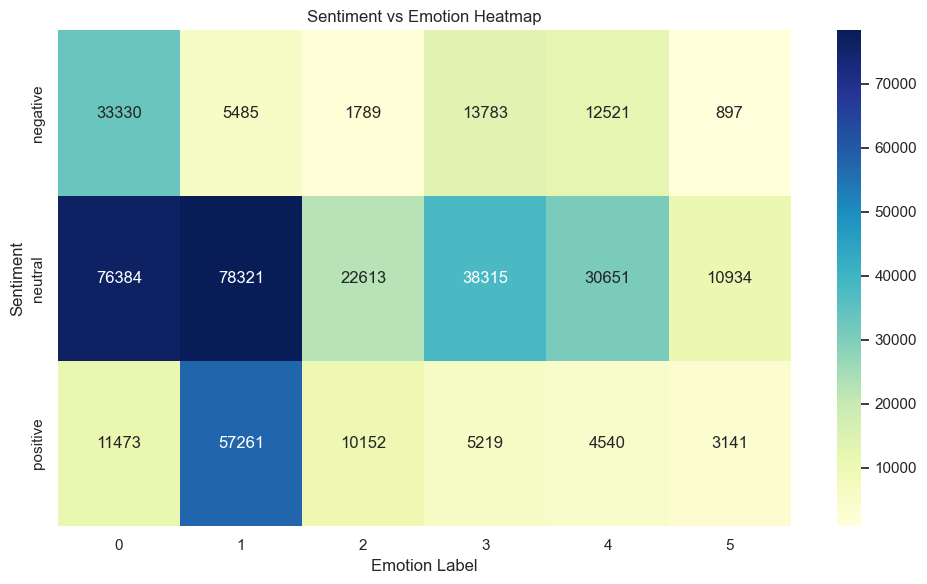

In [37]:
plt.figure(figsize=(10, 6))
sns.heatmap(sentiment_emotion, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Sentiment vs Emotion Heatmap")
plt.xlabel("Emotion Label")
plt.ylabel("Sentiment")
plt.tight_layout()
plt.show()

In [38]:
# 15. PERCENTAGE HEATMAP


===== SENTIMENT × EMOTION (%) =====


label,0,1,2,3,4,5
sentiment,,,,,,
negative,49.16,8.09,2.64,20.33,18.47,1.32
neutral,29.70,30.45,8.79,14.90,11.92,4.25
positive,12.50,62.39,11.06,5.69,4.95,3.42


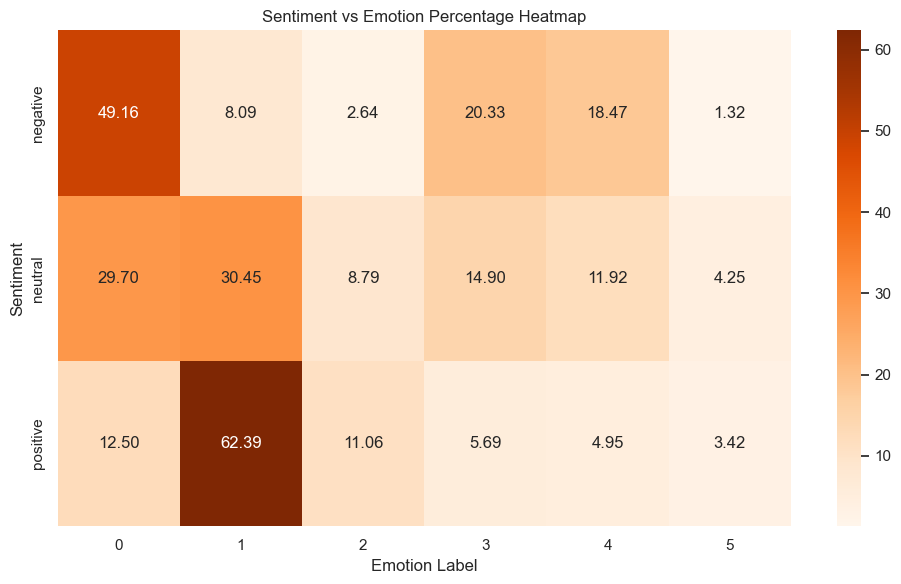

In [39]:
sentiment_emotion_percent = (
    pd.crosstab(df["sentiment"], df["label"], normalize="index") * 100
)

print("\n===== SENTIMENT × EMOTION (%) =====")
display(sentiment_emotion_percent.round(2))

plt.figure(figsize=(10, 6))
sns.heatmap(
    sentiment_emotion_percent,
    annot=True,
    fmt=".2f",
    cmap="Oranges"
)
plt.title("Sentiment vs Emotion Percentage Heatmap")
plt.xlabel("Emotion Label")
plt.ylabel("Sentiment")
plt.tight_layout()
plt.show()

In [40]:
# 16. CATEGORICAL ENCODING

In [41]:
df["sentiment_encoded"] = pd.Categorical(df["sentiment"]).codes

df["length_category_encoded"] = pd.Categorical(
    df["text_length_category"],
    categories=["Short", "Medium", "Long", "Very Long"],
    ordered=True
).codes

In [42]:
# 17. CORRELATION HEATMAP


===== CORRELATION MATRIX =====


,label,sentiment_encoded,text_length,length_category_encoded
label,1.000,-0.040,0.025,0.027
sentiment_encoded,-0.040,1.000,0.077,0.078
text_length,0.025,0.077,1.000,0.913
length_category_encoded,0.027,0.078,0.913,1.000


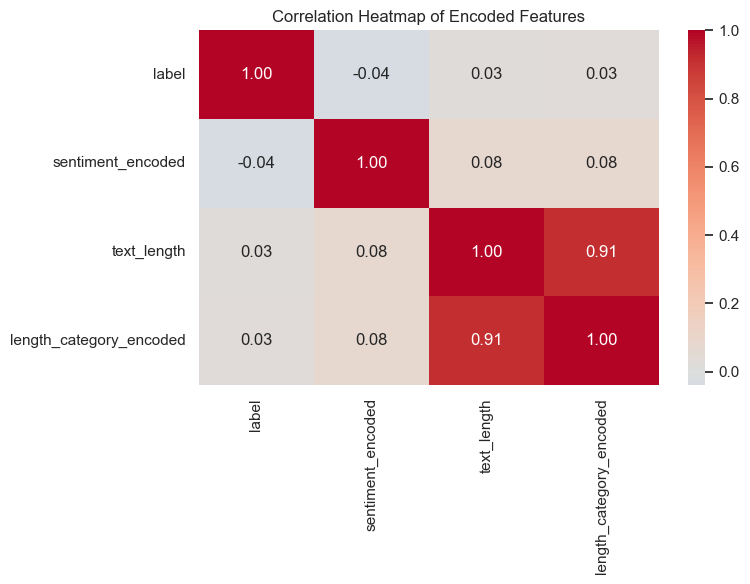

In [43]:
correlation_data = df[
    [
        "label",
        "sentiment_encoded",
        "text_length",
        "length_category_encoded"
    ]
]

print("\n===== CORRELATION MATRIX =====")
display(correlation_data.corr().round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_data.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap of Encoded Features")
plt.tight_layout()
plt.show()

In [44]:
# 18. EMOTION × TEXT LENGTH CATEGORY (%)

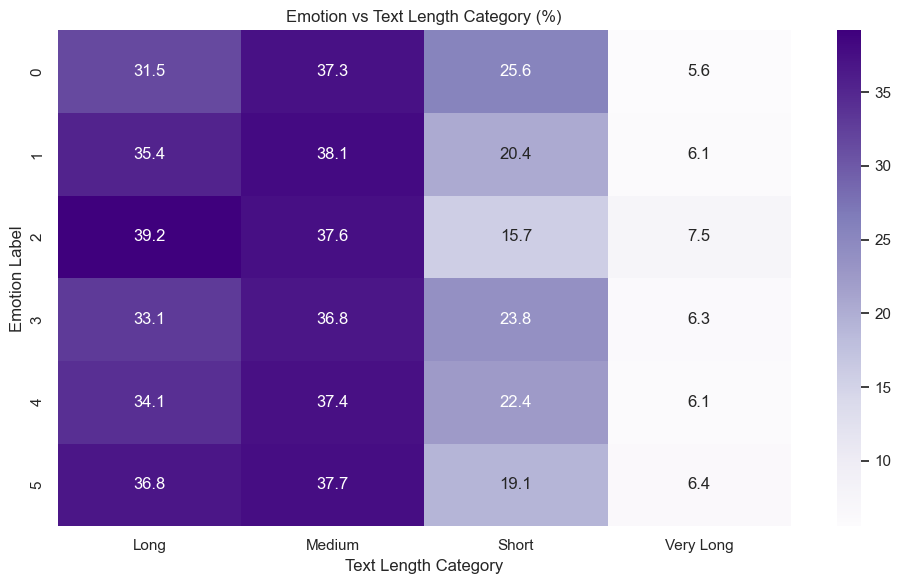

In [45]:
emotion_length_percentage = (
    pd.crosstab(
        df["label"],
        df["text_length_category"],
        normalize="index"
    ) * 100
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    emotion_length_percentage,
    annot=True,
    fmt=".1f",
    cmap="Purples"
)
plt.title("Emotion vs Text Length Category (%)")
plt.xlabel("Text Length Category")
plt.ylabel("Emotion Label")
plt.tight_layout()
plt.show()

In [46]:
# 19. VIOLIN PLOT

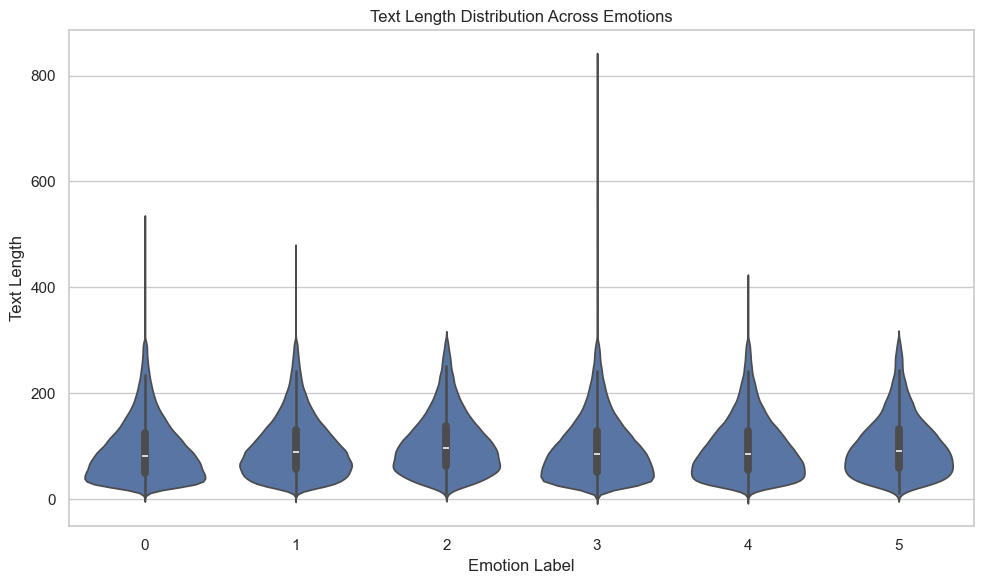

In [47]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="label", y="text_length")
plt.title("Text Length Distribution Across Emotions")
plt.xlabel("Emotion Label")
plt.ylabel("Text Length")
plt.tight_layout()
plt.show()

In [48]:
# 20. EMPTY TEXT

In [49]:
empty_text = (
    df["text"].astype(str).str.strip().eq("").sum()
)

print("\n===== EMPTY TEXT =====")
print(empty_text)


===== EMPTY TEXT =====
0


In [50]:
# 21. TEXT DUPLICATES

In [51]:
text_duplicates = df["text"].duplicated().sum()

print("\n===== TEXT DUPLICATES =====")
print("Duplicate text entries:", text_duplicates)
print(
    "Duplicate percentage:",
    f"{text_duplicates / len(df) * 100:.2f}%"
)


===== TEXT DUPLICATES =====
Duplicate text entries: 686
Duplicate percentage: 0.16%


In [52]:
# 22. DUPLICATE TEXT LABEL CONSISTENCY

In [53]:
duplicate_texts = df[df["text"].duplicated(keep=False)]

print("\n===== DUPLICATE TEXT LABEL CONSISTENCY =====")
print("Duplicate rows:", len(duplicate_texts))
print(
    "Unique duplicate texts:",
    duplicate_texts["text"].nunique()
)

conflicting = (
    duplicate_texts
    .groupby("text")
    .agg(
        emotion_classes=("label", "nunique"),
        sentiment_classes=("sentiment", "nunique")
    )
)

conflicting = conflicting[
    (conflicting["emotion_classes"] > 1) |
    (conflicting["sentiment_classes"] > 1)
]

print(
    "Duplicate texts with different labels:",
    conflicting.shape[0]
)


===== DUPLICATE TEXT LABEL CONSISTENCY =====
Duplicate rows: 1250
Unique duplicate texts: 564
Duplicate texts with different labels: 0


In [54]:
# 23. LABEL SUMMARY

In [55]:
label_summary = (
    df.groupby("label")
    .agg(
        samples=("label", "size"),
        avg_text_length=("text_length", "mean"),
        min_text_length=("text_length", "min"),
        max_text_length=("text_length", "max")
    )
    .round(2)
)

print("\n===== LABEL SUMMARY =====")
display(label_summary)


===== LABEL SUMMARY =====


,samples,avg_text_length,min_text_length,max_text_length
label,,,,
0,121187,93.29,6,525
1,141067,99.07,5,470
2,34554,106.15,10,303
3,57317,96.36,4,830
4,47712,97.37,5,411
5,14972,101.06,12,302


In [56]:
# 24. SENTIMENT SUMMARY

In [57]:
sentiment_summary = (
    df.groupby("sentiment")
    .agg(
        samples=("sentiment", "size"),
        avg_text_length=("text_length", "mean"),
        min_text_length=("text_length", "min"),
        max_text_length=("text_length", "max")
    )
    .round(2)
)

print("\n===== SENTIMENT SUMMARY =====")
display(sentiment_summary)


===== SENTIMENT SUMMARY =====


,samples,avg_text_length,min_text_length,max_text_length
sentiment,,,,
negative,67805,100.16,10,830
neutral,257218,91.72,4,470
positive,91786,111.64,11,375
